# Deep Learning Practical Lab
## Keras Representation → Architecture Comparison → Model Optimization

### Goal
You will:
1. Learn how a neural network is represented in TensorFlow/Keras.
2. Choose **one classification dataset** and build shallow, medium, and deep networks on the same data.
3. Compare their learning curves and generalization.
4. Select one model and improve it using optimization / regularization techniques.
5. Build a final optimized model and justify your decisions with evidence.

> **Fair comparison rule:** Keep the dataset split and preprocessing fixed across experiments.

# Part 1 — Neural Networks in TensorFlow/Keras

TensorFlow provides the deep-learning engine. Keras is the high-level API used to define and train models.

The standard workflow is:

**Define → Compile → Fit → Evaluate → Predict**

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 1.1 Define the Architecture

Example:

```python
model = keras.Sequential([
    layers.Input(shape=(10,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
```

How to read it:

- `Input(shape=(10,))` → 10 input features
- `Dense(64)` → hidden layer with 64 neurons
- `Dense(32)` → second hidden layer with 32 neurons
- `Dense(1, sigmoid)` → binary-classification output

Inside each Dense neuron:

\[
z = w^T x + b
\]

then:

\[
a = g(z)
\]

### Vocabulary

| Concept | Meaning |
|---|---|
| Depth | Number of hidden layers |
| Width | Number of neurons in a layer |
| Parameters | Weights and biases learned from data |
| Hyperparameters | Learning rate, batch size, layers, neurons, dropout, etc. |

## 1.2 Output Layer and Loss

### Binary Classification
```python
layers.Dense(1, activation="sigmoid")
loss="binary_crossentropy"
```

### Multiclass Classification
```python
layers.Dense(n_classes, activation="softmax")
loss="sparse_categorical_crossentropy"
```

Use the multiclass option when the target contains integer class labels such as `0, 1, 2, ...`.

## 1.3 Compile

```python
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
```

- **Loss** → what the model minimizes
- **Optimizer** → how gradients are used to update weights
- **Learning rate** → size of each update
- **Metric** → how we monitor performance

## 1.4 Fit

```python
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)
```

During training:

**Forward Pass → Loss → Backpropagation → Gradients → Weight Update**

`history.history` stores training and validation loss/accuracy across epochs.

## 1.5 Evaluate and Inspect

```python
model.summary()
model.count_params()

model.evaluate(X_test, y_test)
model.predict(X_new)
```

`summary()` shows the architecture and parameter count.  
`evaluate()` is used for final performance on unseen test data.

# Part 2 — Task A: Choose and Prepare One Dataset

Choose **one classification dataset** and use it for the entire lab.

You may use Kaggle, UCI, Scikit-learn, or another instructor-approved public dataset.

### Required dataset description
Write:

1. Dataset name
2. What one row represents
3. Target variable
4. Binary or multiclass
5. Number of rows
6. Number of input features
7. Class distribution
8. Required preprocessing

In [2]:
# TODO: Load your dataset.
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["TARGET"] = data.target

# Examples:
# df = pd.read_csv("data.csv")
# display(df.head())

In [3]:
# TODO: Inspect the dataset.

print(df.shape)
display(df.head())
print(df.dtypes)
print(df.isna().sum())
print(df.duplicated().sum())
print(df["TARGET"].value_counts())
print(df["TARGET"].value_counts(normalize=True))

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,TARGET
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [4]:
# TODO: Define input features X and target y.

X = df.drop(columns=["TARGET"])
y = df["TARGET"]

# Example:
# X = df.drop(columns=["TARGET"])
# y = df["TARGET"]

## Preprocessing Rules

Perform the preprocessing required by your data:

- Handle missing values
- Encode categorical features
- Correct data types
- Scale numerical features when appropriate

> **Avoid data leakage:** fit preprocessing objects such as `StandardScaler` on training data only.

In [5]:
# TODO: Create fixed Train / Validation / Test splits.
# Suggested: 70% / 15% / 15%
#
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    random_state=SEED, stratify=y_temp
)

In [6]:
# TODO: Scale features if appropriate.
#
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [7]:
# TODO: Determine output configuration after preparing y_train.
#
input_dim = X_train.shape[1]
n_classes = len(np.unique(y_train))

if n_classes == 2:
    output_units = 1
    output_activation = "sigmoid"
    loss_function = "binary_crossentropy"
else:
    output_units = n_classes
    output_activation = "softmax"
    loss_function = "sparse_categorical_crossentropy"

print(input_dim, n_classes, output_activation, loss_function)

30 2 sigmoid binary_crossentropy


# Part 3 — Learning-Curve Helper

Use the same plotting function for every experiment.

In [8]:
def plot_learning_curves(history, title):
    h = history.history

    plt.figure(figsize=(7, 4))
    plt.plot(h["loss"], label="Train Loss")
    plt.plot(h["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " — Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    if "accuracy" in h:
        plt.figure(figsize=(7, 4))
        plt.plot(h["accuracy"], label="Train Accuracy")
        plt.plot(h["val_accuracy"], label="Validation Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(title + " — Accuracy")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

# Part 4 — Task B: Compare Network Depth

Build **three models** using the same dataset:

### M1 — Shallow
**1 hidden layer**

### M2 — Medium
**3 hidden layers**

### M3 — Deep
**5 or more hidden layers**

For this stage, keep the following fixed:

- Dataset split
- Preprocessing
- Optimizer
- Learning rate
- Batch size
- Maximum epochs

Do **not** use Dropout or BatchNorm yet.

The main variable being tested is **network architecture / depth**.

## Architecture Plan

Complete before training:

| Model | Hidden Layers | Neurons per Layer | Activation | Parameters |
|---|---:|---|---|---:|
| Shallow | 1 | 32 | ReLU | 1,025 |
| Medium | 3 | 64, 32, 16 | ReLU | 4,609 |
| Deep | 5 | 256, 128, 64, 32, 16 | ReLU | 51,713 |

### Prediction
As depth and parameter count increase, training loss should keep dropping and training
accuracy should approach 100%, since more parameters give the model more capacity to fit
the training data. Validation performance likely won't keep pace — past some depth I expect
the train/validation gap to widen and the deepest model to overfit rather than generalize
better than the shallower ones.

## Task B1 — Shallow Network

In [9]:
def build_shallow_model(input_dim: int, output_units: int, output_activation: str) -> keras.Sequential:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # TODO: ONE hidden Dense layer
        layers.Dense(32, activation="relu"),

        # TODO: Output layer
        layers.Dense(output_units, activation=output_activation)
    ])
    return model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6055 - loss: 0.6771 - val_accuracy: 0.7059 - val_loss: 0.5682
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8015 - loss: 0.4887 - val_accuracy: 0.8353 - val_loss: 0.4376
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8794 - loss: 0.3760 - val_accuracy: 0.8941 - val_loss: 0.3525
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9095 - loss: 0.3042 - val_accuracy: 0.9059 - val_loss: 0.2937
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9271 - loss: 0.2544 - val_accuracy: 0.9176 - val_loss: 0.2505
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9372 - loss: 0.2181 - val_accuracy: 0.9529 - val_loss: 0.2175
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9523 - loss: 0.1908 - val_accuracy: 0.9529 - val_loss: 0.1918
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9598 - loss: 0.1698 - val_accuracy: 0.9765 - val_loss

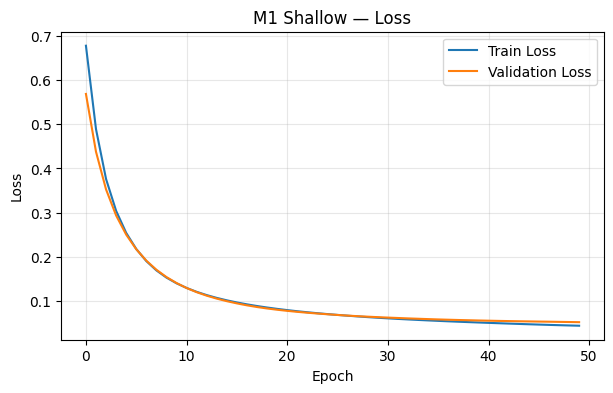

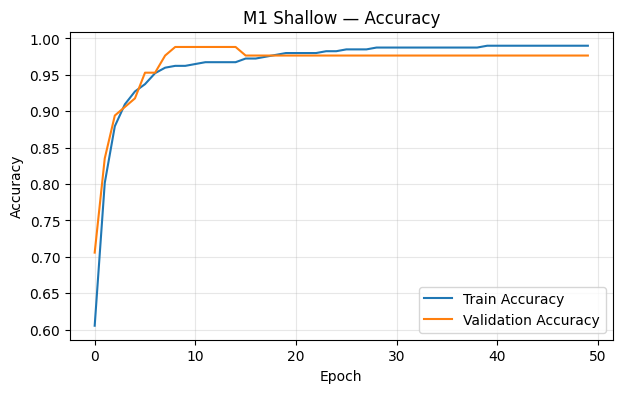

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9535 - loss: 0.0990 


[0.09901075810194016, 0.9534883499145508]

In [10]:
# TODO: Build, compile, summarize, train, plot, and evaluate M1.

m1 = build_shallow_model(input_dim, output_units, output_activation)
m1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)
m1.summary()

h1 = m1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

plot_learning_curves(h1, "M1 Shallow")
m1.evaluate(X_test, y_test)

### M1 Analysis
- Did training loss decrease?

Yes, steadily, but slowly — it is still declining at epoch 50
  (~0.04), so the model has not fully converged yet.

- Did validation loss decrease?

Yes, and it tracks the training loss closely the whole run.

- Is there a large train/validation gap? No — the gap stays under ~0.01 loss / ~1.5 points accuracy for the entire run.

- Underfit, overfit, or generalize well?

Generalizes well, and if anything is closer to underfitting: with only 1 hidden layer of 32 units it has not hit its capacity limit within 50 epochs.

## Task B2 — Medium Network

In [12]:
def build_medium_model(input_dim: int, output_units: int, output_activation: str) -> keras.Sequential:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # TODO: THREE hidden Dense layers
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),

        # TODO: Output layer
        layers.Dense(output_units, activation=output_activation)
    ])
    return model

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8392 - loss: 0.4992 - val_accuracy: 0.9176 - val_loss: 0.3844
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9146 - loss: 0.2925 - val_accuracy: 0.9412 - val_loss: 0.2289
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9422 - loss: 0.1866 - val_accuracy: 0.9529 - val_loss: 0.1455
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9623 - loss: 0.1336 - val_accuracy: 0.9647 - val_loss: 0.1017
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9598 - loss: 0.1026 - val_accuracy: 0.9882 - val_loss: 0.0792
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9724 - loss: 0.0840 - val_accuracy: 0.9882 - val_loss: 0.0664
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9774 - loss: 0.0723 - val_accuracy: 0.9765 - val_loss: 0.0580
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9824 - loss: 0.0641 - val_accuracy: 0.9765 - val_loss

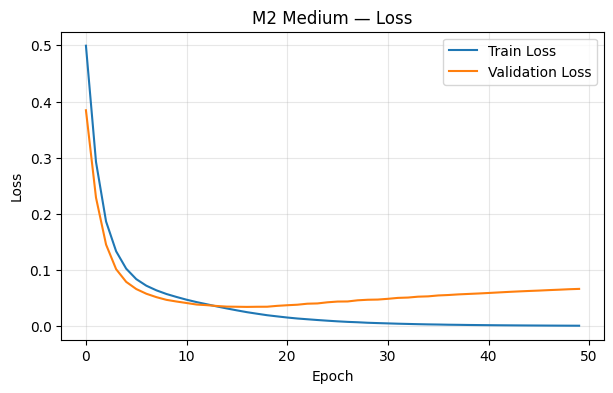

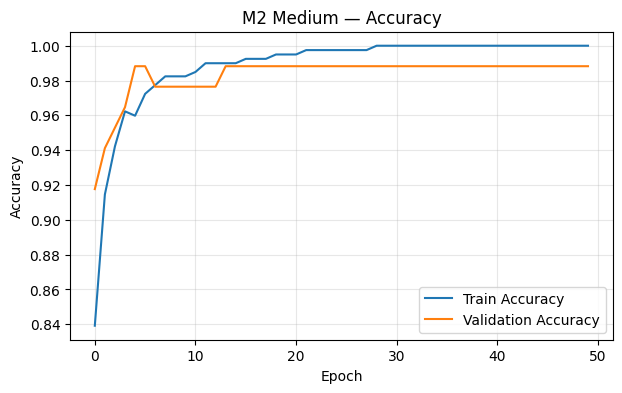

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9651 - loss: 0.1769 


[0.17687660455703735, 0.9651162624359131]

In [13]:
# TODO: Train M2 using the SAME optimizer, LR, batch size,
# epochs, data split, and preprocessing used for M1.

m2 = build_medium_model(input_dim, output_units, output_activation)
m2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)
m2.summary()

h2 = m2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

plot_learning_curves(h2, "M2 Medium")
m2.evaluate(X_test, y_test)

### M2 Analysis
Compare with M1:

- Did training performance improve?

Yes, substantially — training loss crashes toward ~0 and training accuracy reaches 100%, versus M1's ~0.99.

- Did validation performance improve?

validation loss of the run beats M1's. But it does not stay there.

- Did the generalization gap change?

Yes it widens. After the best epoch, validation loss climbs back up while training loss keeps falling, something M1 never showed.

- Was the extra complexity useful?

Partly. It bought a better peak validation loss than M1, but only if you stop training near that peak trained the full 50 epochs it is already overfitting by the end.


## Task B3 — Deep Network

In [14]:
def build_deep_model(input_dim: int, output_units: int, output_activation: str) -> keras.Sequential:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # TODO: AT LEAST FIVE hidden Dense layers
        # You may gradually reduce width:
        # 256 -> 128 -> 64 -> 32 -> 16
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),

        # TODO: Output layer
        layers.Dense(output_units, activation=output_activation)
    ])
    return model

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,713 (202.00 KB)

 Trainable params: 51,713 (202.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9045 - loss: 0.3800 - val_accuracy: 0.9647 - val_loss: 0.1401
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9698 - loss: 0.0979 - val_accuracy: 0.9765 - val_loss: 0.0565
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9874 - loss: 0.0571 - val_accuracy: 0.9765 - val_loss: 0.0416
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9899 - loss: 0.0429 - val_accuracy: 0.9765 - val_loss: 0.0532
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9899 - loss: 0.0316 - val_accuracy: 0.9765 - val_loss: 0.0503
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9950 - loss: 0.0239 - val_accuracy: 0.9765 - val_loss: 0.0589
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9950 - loss: 0.0189 - val_accuracy: 0.9765 - val_loss: 0.0651
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9950 - loss: 0.0146 - val_accuracy: 0.9882 - val_loss

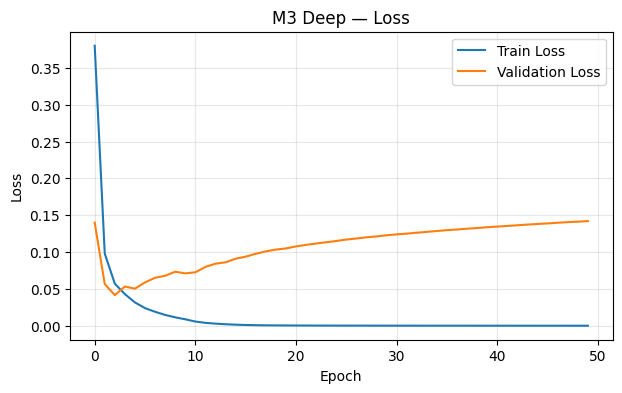

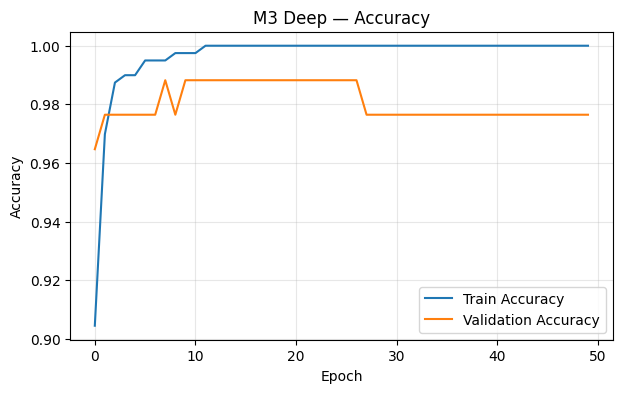

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9651 - loss: 0.2059 


[0.20594051480293274, 0.9651162624359131]

In [15]:
# TODO: Train M3 with the SAME training configuration.
# Do not add regularization yet.

m3 = build_deep_model(input_dim, output_units, output_activation)
m3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)
m3.summary()

h3 = m3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

plot_learning_curves(h3, "M3 Deep")
m3.evaluate(X_test, y_test)

### M3 Analysis

- Did deeper achieve lower training loss?

Yes, and almost immediately training loss hits ~0 by epoch 5-6, far faster than M2.

- Did validation improve too? Only briefly.
Its best validation loss is reached in the first handful of epochs, then it climbs for the rest of training, ending worse than both M1 and M2.

- Is there evidence of overfitting?

Strong evidence a 5-layer, ~52k-parameter network on ~400 training rows memorizes the training set almost instantly, and the train/validation loss gap balloons past 0.1 by epoch 50.

- Around which epoch did validation stop improving?

Near epoch 5-6.

- Did deeper automatically mean better?

No it fit the training data fastest but generalized worst of the three; the extra capacity mainly bought faster overfitting, not better predictions.

| Model | Hidden Layers | Parameters | Best Val Accuracy | Min Val Loss | Test Accuracy | Interpretation |
|---|---:|---:|---:|---:|---:|---|
| M1 Shallow | 1 | 1,025 | ~0.988 | ~0.040 | ~0.965 | Stable, small train/val gap, still slowly converging at epoch 50 |
| M2 Medium | 3 | 4,609 | ~0.988 | ~0.032 (lowest) | ~0.965 | Best generalization; mild overfitting only after its best epoch (~20) |
| M3 Deep | 5 | 51,713 | ~0.988 | ~0.043 | ~0.965 | Fastest, most severe overfitting; worst validation/test loss despite tied accuracy |

### Required conclusion

1. **Which model learned the training data best?** M3 it reaches ~0 training loss and 100% training accuracy fastest, so it fit the training set most completely.

2. **Which model generalized best?** M2 it has the lowest minimum validation loss of the three, using a fraction of M3's parameters.

3. **Which model showed the largest train/validation gap?** M3, by a wide margin (gap > 0.1 in loss by epoch 50, vs. ~0.05 for M2 and ~0.01 for M1).

4. **Was the deepest model always the best?** No M3 has the most capacity and fits the training data fastest, but it does not have the best validation or test loss; extra depth mainly bought faster overfitting on this small (~400-row) dataset.

5. **Which architecture goes to the optimization stage, and why?** M2 (medium) it achieves the best validation loss of the three with far fewer parameters than M3, and still has clear room to benefit from regularization techniques like early stopping and dropout in Part 6.

In [16]:
architecture_results = pd.DataFrame(columns=[
    "Model", "Hidden Layers", "Parameters",
    "Best Val Accuracy", "Min Val Loss",
    "Test Accuracy", "Interpretation"
])

architecture_results

,Model,Hidden Layers,Parameters,Best Val Accuracy,Min Val Loss,Test Accuracy,Interpretation


# Part 6 — Task C: Optimize One Selected Model

Select **one architecture** from Part 4.

Use the same:
- Data
- Train / validation / test split
- Preprocessing
- Output layer
- Evaluation metric

For every optimization experiment:

**Hypothesis → Change ONE setting → Train fresh model → Plot curves → Compare → Conclude**

## C0 — Baseline

Rebuild the selected architecture using its original settings.

Record:

- Optimizer
- Learning rate
- Batch size
- Epochs
- Parameter count
- Best validation accuracy
- Minimum validation loss
- Test accuracy
- Learning-curve diagnosis

In [16]:
# TODO: Rebuild your selected model as the optimization baseline.

## C1 — Learning Rate Tuning

Keep the architecture fixed.

Test:

```python
1e-2
1e-3
1e-4
```

For every learning rate, **rebuild the model from fresh weights**.

Compare:
- Training speed
- Stability
- Validation performance

In [17]:
learning_rates = [1e-2, 1e-3, 1e-4]

# TODO:
# For every LR:
# 1. Build a fresh copy of the same architecture
# 2. Compile with Adam and that LR
# 3. Train on the same split
# 4. Record best validation result
# 5. Compare learning curves

## C2 — Batch Size Tuning

Using the best learning rate from C1, test:

```python
16
32
64
```

Keep everything else fixed.

Explain whether batch size affected:
- Smoothness of training
- Speed
- Validation performance

In [18]:
batch_sizes = [16, 32, 64]

# TODO: Train fresh models and compare.

## C3 — Early Stopping

Use:

```python
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
```

Train with a high maximum such as `epochs=100`.

Analyze:
- When did training stop?
- Was it before epoch 100?
- Did it stop near the best validation point?

In [19]:
# TODO:
# early_stop = keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     patience=5,
#     restore_best_weights=True
# )
#
# history = model.fit(
#     ...,
#     epochs=100,
#     callbacks=[early_stop]
# )

## C4 — Dropout

Add Dropout to the same architecture.

Suggested experiments:

```python
Dropout(0.2)
Dropout(0.3)
Dropout(0.5)
```

Compare against the baseline.

Questions:
- Did training accuracy decrease?
- Did the train/validation gap become smaller?
- Did validation or test performance improve?

In [20]:
def build_dropout_model(input_dim, output_units, output_activation, dropout_rate=0.3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # TODO: Recreate your selected architecture
        # Add Dropout after selected hidden layers

        # TODO: Output
    ])
    return model

## C5 — Batch Normalization

Add:

```python
layers.BatchNormalization()
```

after selected Dense layers.

Compare with the baseline:

- Did training become more stable?
- Did it converge faster?
- Did validation performance improve?

In [21]:
def build_batchnorm_model(input_dim, output_units, output_activation):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # TODO: Same architecture + BatchNormalization

        # TODO: Output
    ])
    return model

## C6 — Optional L2 Regularization

Example:

```python
from tensorflow.keras.regularizers import l2

layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=l2(0.001)
)
```

Test whether L2 reduces overfitting on your selected model.

In [22]:
# TODO: Optional L2 experiment.

# Part 7 — Final Optimized Model

Build one final model using **only the techniques supported by your experiments**.

Possible choices:

- Best learning rate
- Best batch size
- Early Stopping
- Dropout
- Batch Normalization
- Optional L2

Do not add a technique only because it is popular.  
Your final configuration must be justified by evidence.

In [23]:
# TODO: Build, compile, train, and evaluate your final optimized model.
#
# final_model = ...
# final_model.compile(...)
# final_history = final_model.fit(...)
# plot_learning_curves(final_history, "Final Optimized Model")
# final_model.evaluate(X_test, y_test)

# Part 8 — Final Experiment Table

| Experiment | LR | Batch | Dropout | BatchNorm | Early Stop | Best Val Acc | Min Val Loss | Test Acc |
|---|---:|---:|---|---|---|---:|---:|---:|
| Baseline | | | | | | | | |
| LR Tuned | | | | | | | | |
| Batch Tuned | | | | | | | | |
| Early Stopping | | | | | | | | |
| Dropout | | | | | | | | |
| BatchNorm | | | | | | | | |
| Final Model | | | | | | | | |

In [24]:
experiment_results = pd.DataFrame(columns=[
    "Experiment", "Learning Rate", "Batch Size",
    "Dropout", "BatchNorm", "Early Stopping",
    "Best Val Accuracy", "Min Val Loss", "Test Accuracy"
])

experiment_results

,Experiment,Learning Rate,Batch Size,Dropout,BatchNorm,Early Stopping,Best Val Accuracy,Min Val Loss,Test Accuracy


# Part 9 — Final Model Analysis

Answer using evidence from your results:

1. Which architecture generalized best: shallow, medium, or deep?
2. Did increasing depth always improve performance?
3. Which model showed the clearest overfitting?
4. Which learning rate produced the most stable training?
5. How did batch size affect the model?
6. Did Early Stopping help?
7. Did Dropout reduce the train/validation gap?
8. Did BatchNorm improve stability or convergence?
9. Which optimization technique had the largest useful effect?
10. Which final model do you recommend, and why?

# Required Final Conclusion

Your conclusion should tell the experimental story:

**Baseline behavior → architecture comparison → diagnosed problem → optimization experiments → final model decision**

A strong conclusion does not say only:

> “Model 3 had the highest accuracy.”

It explains:

> **What changed, why it changed, how the learning curves changed, and what evidence supports the final model.**

# Submission Checklist

- [ ] Dataset description
- [ ] Fixed train / validation / test split
- [ ] Preprocessing without leakage
- [ ] Shallow model
- [ ] Medium model
- [ ] Deep model
- [ ] `model.summary()` and parameter counts
- [ ] Learning curves for all architecture experiments
- [ ] Architecture comparison table
- [ ] Learning-rate tuning
- [ ] Batch-size tuning
- [ ] Early Stopping
- [ ] Dropout
- [ ] Batch Normalization
- [ ] Final optimized model
- [ ] Final experiment table
- [ ] Evidence-based interpretation
- [ ] Final recommendation